# 04 Xenium Loading & QC

Starter notebook for Xenium data loading and quality control.

**Goals:**
 - it loads Xenium data (transcripts/cells + spatial geometry) into a usable analysis object.
 - performs QC on Xenium cells/features before downstream annotation.
 - produces a cleaned Xenium object for notebook 5 (annotation/neighborhood analysis).
 - prepares Xenium so we can compare results with Visium/cell2location outputs in notebook 6.

In [1]:
import scanpy as sc
import spatialdata as sd
import spatialdata_io as sdio
import pandas as pd

/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_jo

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white")

PROJECT_ROOT = Path("..")
XENIUM_OUTS = PROJECT_ROOT / "data" / "GSE243280_RAW" / "GSM7780153_Xenium_FFPE_Human_Breast_Cancer_Rep1_outs" / "outs"
XENIUM_H5 = XENIUM_OUTS / "cell_feature_matrix.h5"
OUT_DIR = PROJECT_ROOT / "data" / "xenium"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Xenium outs exists: {XENIUM_OUTS.exists()} -> {XENIUM_OUTS}")
print(f"cell_feature_matrix.h5 exists: {XENIUM_H5.exists()} -> {XENIUM_H5}")

Xenium outs exists: True -> ../data/GSE243280_RAW/GSM7780153_Xenium_FFPE_Human_Breast_Cancer_Rep1_outs/outs
cell_feature_matrix.h5 exists: True -> ../data/GSE243280_RAW/GSM7780153_Xenium_FFPE_Human_Breast_Cancer_Rep1_outs/outs/cell_feature_matrix.h5


/tmp/ipykernel_786785/2891658998.py:6: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white")


## Load Xenium data

In [3]:
adata_xenium = None
sdata = None

try:
    sdata = sdio.xenium(XENIUM_OUTS)
    table_keys = list(sdata.tables.keys())
    if len(table_keys) == 0:
        raise ValueError("No tables found in SpatialData object")
    adata_xenium = sdata.tables[table_keys[0]].copy()
    print("Loaded via spatialdata_io.xenium")
    print("Table key:", table_keys[0])
except Exception as err:
    print(f"spatialdata_io.xenium failed ({type(err).__name__}: {err})")
    print("Falling back to Scanpy 10x H5 loader")
    adata_xenium = sc.read_10x_h5(XENIUM_H5)
    adata_xenium.var_names_make_unique()

adata_xenium.layers["counts"] = adata_xenium.X.copy()
print(adata_xenium)

/tmp/ipykernel_786785/3930895429.py:5: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = sdio.xenium(XENIUM_OUTS)
/home/katwre/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              
Loaded via spatialdata_io.xenium
Table key: table
AnnData object with n_obs × n_vars = 167780 × 313
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
    layers: 'counts'


## QC metrics and filtering

,count,mean,std,min,25%,50%,75%,max
total_counts,167780.0,191.339569,129.430023,0.0,96.0,164.0,262.0,1359.0
n_genes_by_counts,167780.0,63.204285,24.550799,0.0,48.0,64.0,79.0,194.0
pct_counts_mt,166363.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


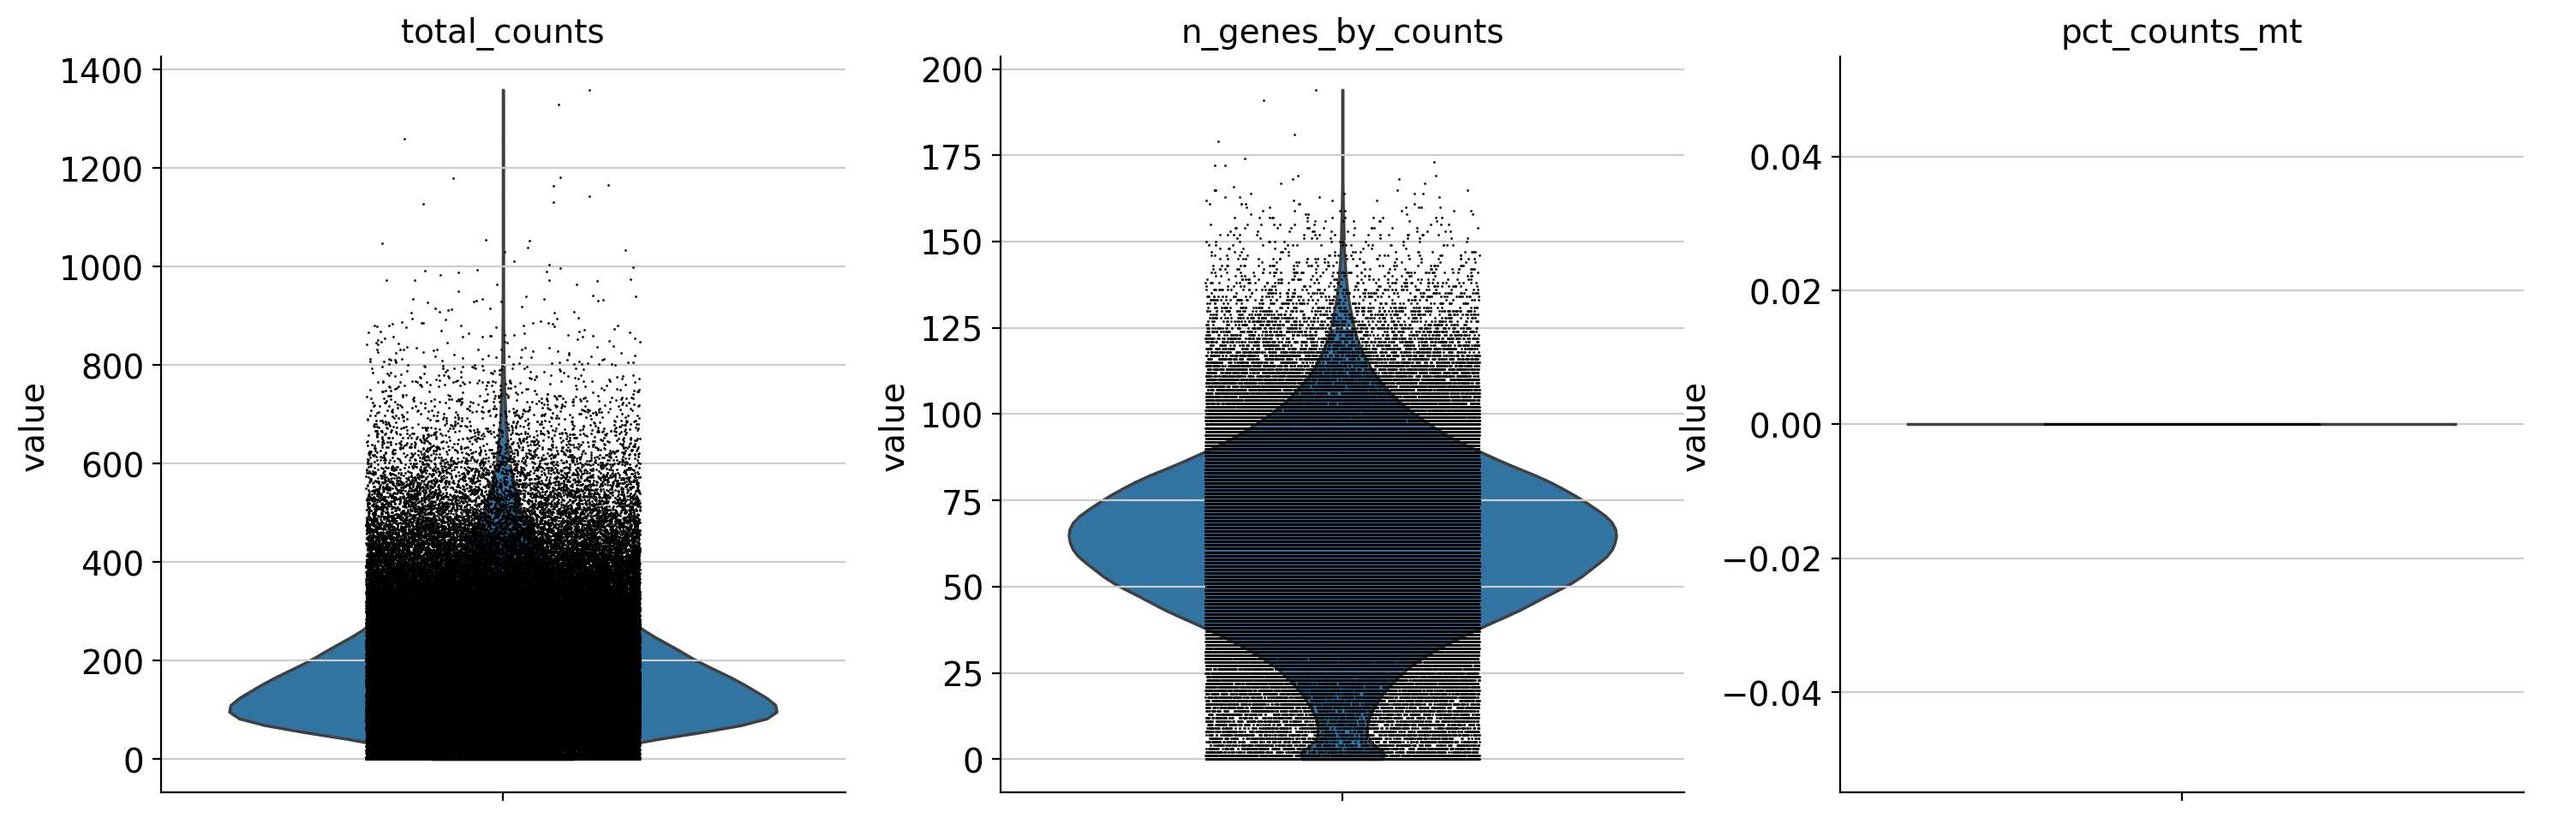

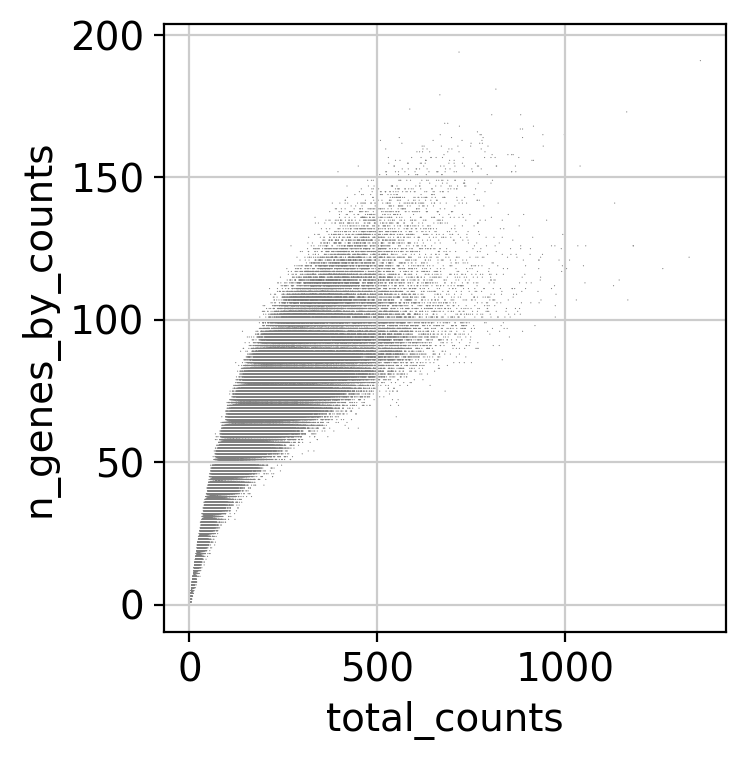

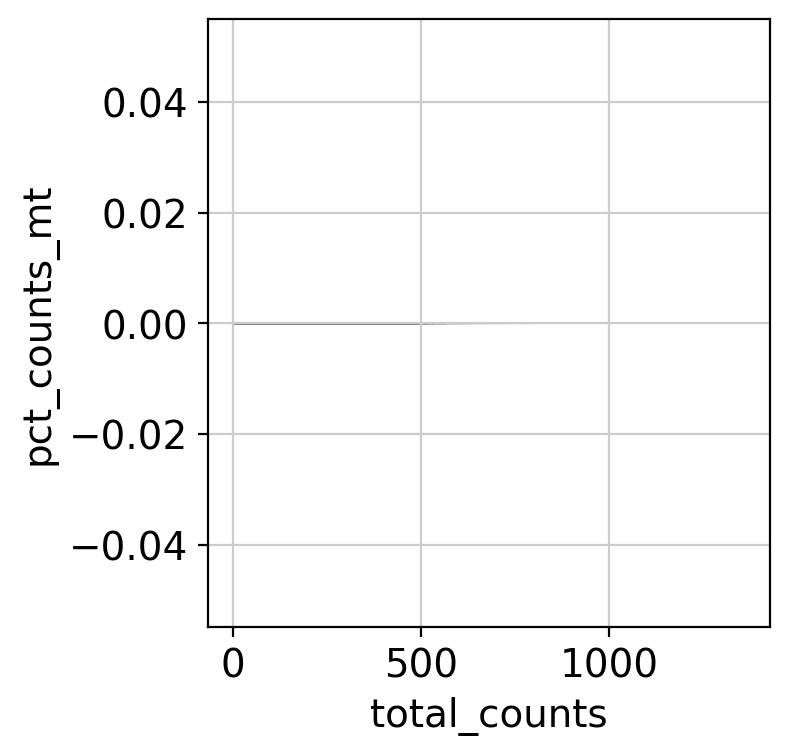

QC thresholds: {'min_genes': 40, 'max_genes': 6000, 'max_mito': 20.0}
Cells before: 167,780
Cells after:  141,868 (84.6%)
AnnData object with n_obs × n_vars = 141868 × 313
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'n_genes_by_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
    layers: 'counts'


In [4]:
adata_xenium.var["mt"] = adata_xenium.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata_xenium, qc_vars=["mt"], percent_top=[20], log1p=False, inplace=True)

qc_cols = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
display(adata_xenium.obs[qc_cols].describe().T)

sc.pl.violin(adata_xenium, qc_cols, jitter=0.2, multi_panel=True)
sc.pl.scatter(adata_xenium, x="total_counts", y="n_genes_by_counts")
sc.pl.scatter(adata_xenium, x="total_counts", y="pct_counts_mt")

xenium_qc_thresholds = {
    "min_genes": 40,
    "max_genes": 6000,
    "max_mito": 20.0,
}

keep_mask = (
    (adata_xenium.obs["n_genes_by_counts"] >= xenium_qc_thresholds["min_genes"])
    & (adata_xenium.obs["n_genes_by_counts"] <= xenium_qc_thresholds["max_genes"])
    & (adata_xenium.obs["pct_counts_mt"] <= xenium_qc_thresholds["max_mito"])
)

print("QC thresholds:", xenium_qc_thresholds)
print(f"Cells before: {adata_xenium.n_obs:,}")
print(f"Cells after:  {keep_mask.sum():,} ({keep_mask.mean():.1%})")

adata_xenium_qc = adata_xenium[keep_mask].copy()
print(adata_xenium_qc)

## Normalize, cluster, and visualize

normalizing counts per cell
    finished (0:00:02)
extracting highly variable genes


/tmp/ipykernel_786785/2058227009.py:4: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata_xenium_work, flavor="seurat_v3", n_top_genes=3000)


computing PCA
    with n_comps=50


/home/katwre/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:05)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:36)
computing UMAP
    finished (0:01:18)
running Leiden clustering
    finished (0:02:03)


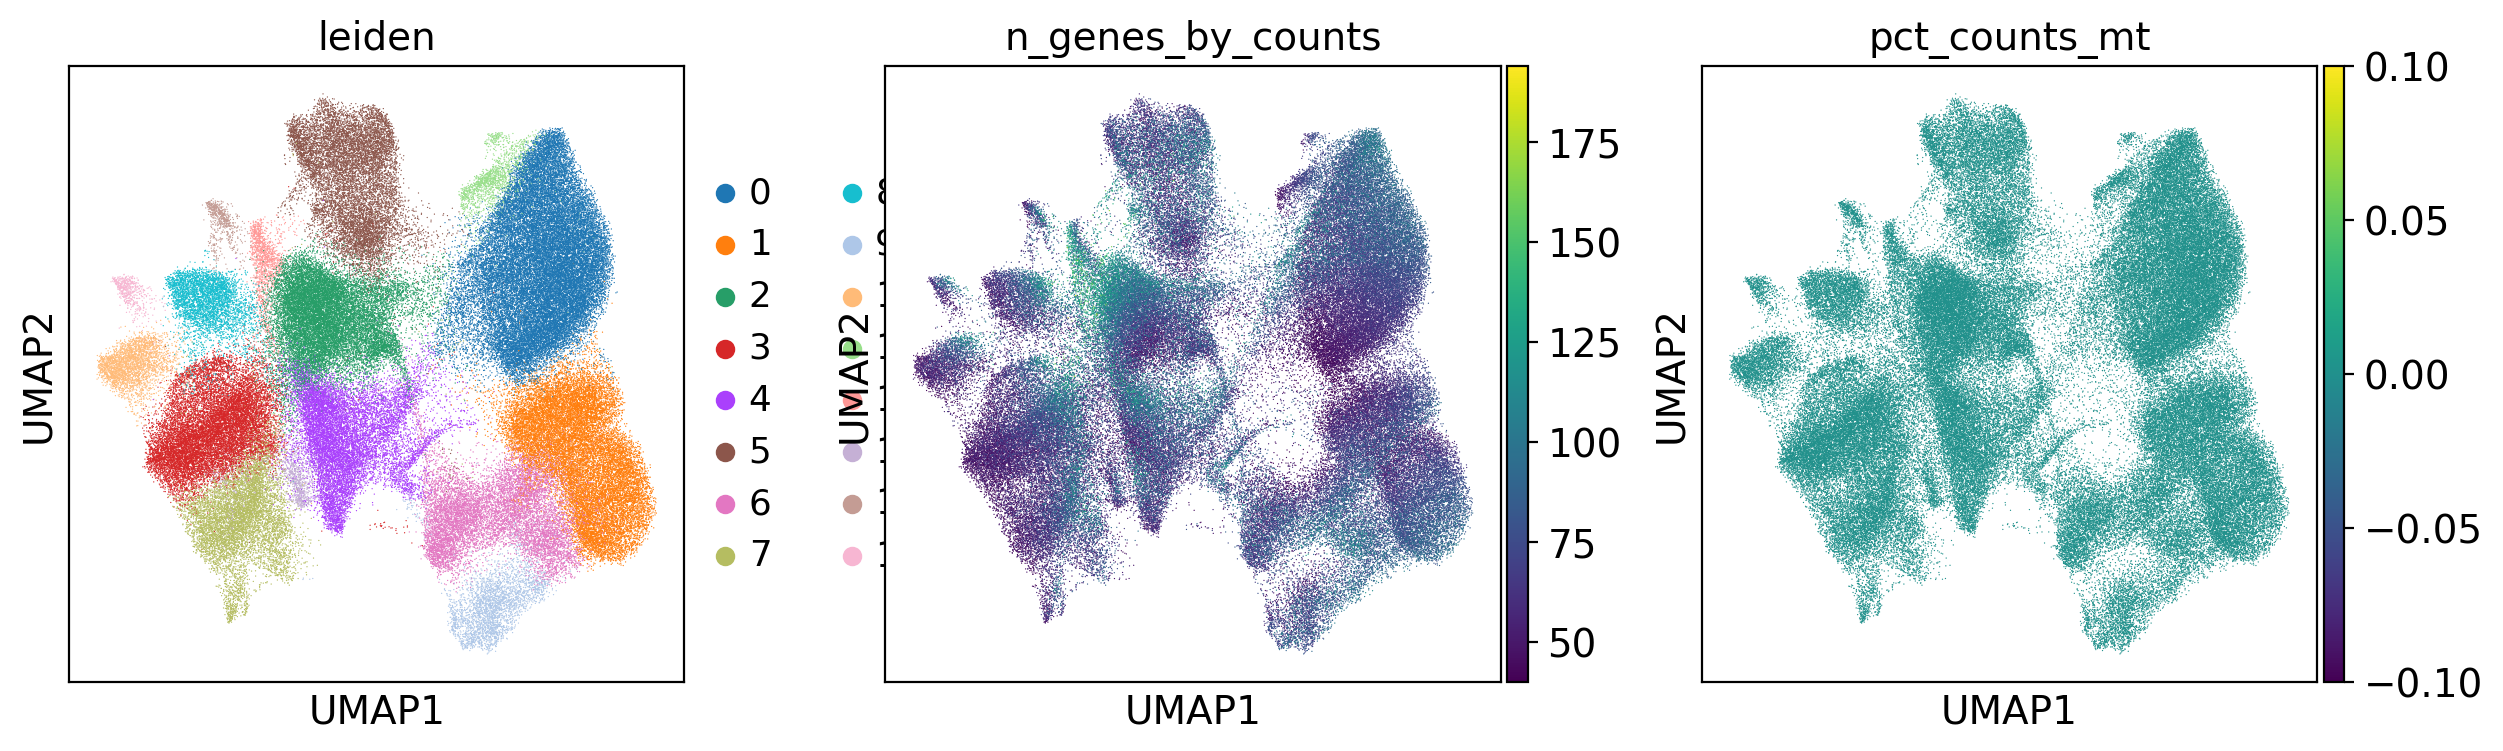

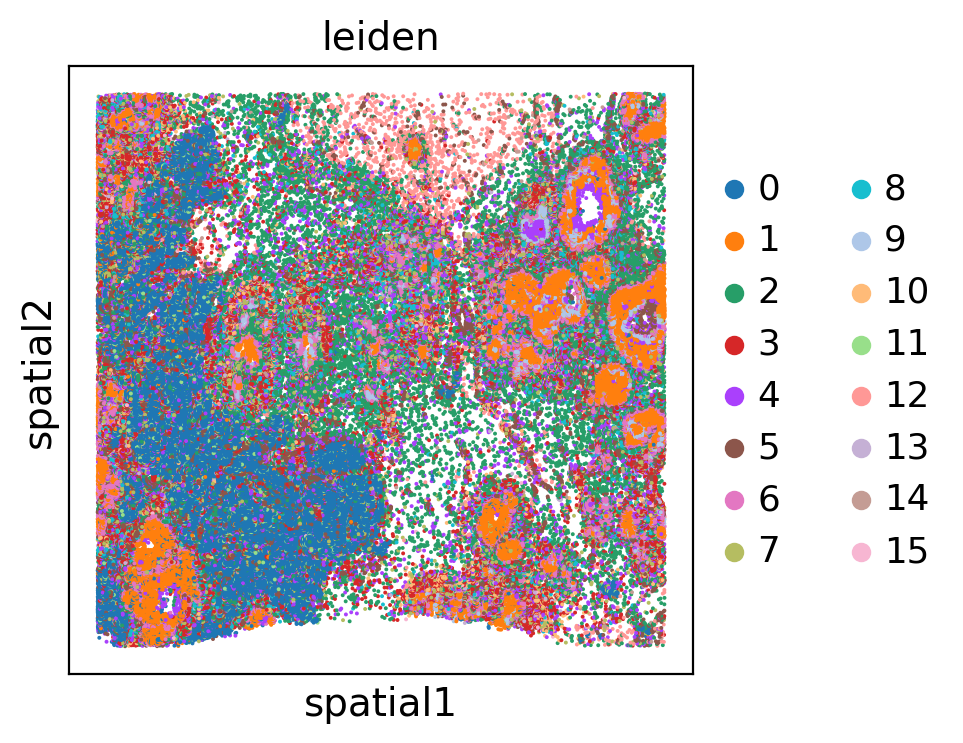

In [5]:
adata_xenium_work = adata_xenium_qc.copy()
sc.pp.normalize_total(adata_xenium_work, target_sum=1e4)
sc.pp.log1p(adata_xenium_work)
sc.pp.highly_variable_genes(adata_xenium_work, flavor="seurat_v3", n_top_genes=3000)
adata_xenium_work = adata_xenium_work[:, adata_xenium_work.var["highly_variable"]].copy()
sc.pp.scale(adata_xenium_work, max_value=10)
sc.tl.pca(adata_xenium_work, svd_solver="arpack")
sc.pp.neighbors(adata_xenium_work, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_xenium_work)
sc.tl.leiden(adata_xenium_work, resolution=0.6)

sc.pl.umap(adata_xenium_work, color=["leiden", "n_genes_by_counts", "pct_counts_mt"])

if "spatial" in adata_xenium_work.obsm:
    sc.pl.embedding(adata_xenium_work, basis="spatial", color=["leiden"], size=8)
else:
    print("No obsm['spatial'] found; skipping spatial embedding plot.")

UMAP has clear structure, but the spatial Leiden map looks highly intermixed, suggesting either broad cell states or clustering resolution/feature choice could be tuned.

In [6]:
xenium_out_fp = OUT_DIR / "xenium_qc_exploration.h5ad"
adata_xenium_work.write_h5ad(xenium_out_fp)
print(f"Saved: {xenium_out_fp}")
print(adata_xenium_work)

Saved: ../data/xenium/xenium_qc_exploration.h5ad
AnnData object with n_obs × n_vars = 141868 × 313
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'n_genes_by_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatialdata_attrs', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
